<a href="https://colab.research.google.com/github/ds3mbc-snu/ds3mbc-snu.github.io/blob/master/2026SHCareerCamp/Lecture2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minimum Spanning Tree 실습: 연결 비용의 하한선과 한계

이 노트북은 수업에서 배운 **Minimum Spanning Tree(MST)** 를
직접 계산하고 눈으로 확인해보는 실습 자료입니다.

## 실습 목표

1. 임의로 만든 그래프에서 MST를 실제로 계산해본다.
2. MST가 그래프의 총 weight 합을 최소화한다는 사실을 데이터로 확인한다.
3. MST를 실제 연결망 설계에 그대로 사용할 때의 장점과 한계를 살펴본다.

각 코드블록은 'Shift+Enter', 또는 코드블록 좌측 상단의 화살표를 눌러 실행할 수 있습니다.

<details open>
<summary>접혀있는 메뉴 설명</summary>

접혀있는 내용은 단순한 코드 실행 이상으로 내용을 이해하기 원하는 학생들을 위한 내용입니다.
이 내용을 이해하지 않아도 코드 실행 및 분석 진행에는 전혀 무리가 없고, 수학과 코딩과 관련해 더 깊은 내용을 보고 싶은 학생들만 읽으면 됩니다.

코드에 달려있는 주석도 별도의 설명이 수반되지 않는 경우에는 이해하지 않아도 괜찮습니다.
</details>

## 0. 준비

아래 셀을 실행하여 실습에 필요한 라이브러리를 불러오고, 그림 제목에 쓰인 한글이 깨지지 않도록 글꼴을 설정합니다.

<details>
<summary>코드 설명</summary>
실습에 필요한 라이브러리를 불러오고, 그림 제목에 쓰인 한글이 깨지지 않도록 글꼴을 설정합니다.

- math: 두 점 사이의 거리를 계산할 때 사용하는 표준 수학 라이브러리
- random: 무작위로 하나를 골라낼 때 사용하는 표준 라이브러리
- numpy: 난수 생성 등 수치 계산에 사용하는 라이브러리
- networkx: 그래프를 다루는 라이브러리
- matplotlib: 그래프를 그림으로 그리는 라이브러리
- pandas: 계산 결과를 표(데이터프레임) 형태로 정리하는 라이브러리

Colab의 기본 글꼴은 한글을 지원하지 않아 그림 제목의 한글이 깨져 보일 수 있습니다. 한글을 지원하는 '나눔고딕' 글꼴을 설치하고, matplotlib이 이 글꼴을 쓰도록 설정합니다.
</details>


In [ ]:
!pip -q install networkx matplotlib pandas numpy

import math
import random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

!apt -qq install fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

print("준비 완료")

준비 완료


## 1. 실습 파라미터

아래 값은 실습에 사용할 그래프를 만드는 데 필요한 값입니다.

- `N`: 꼭짓점의 수
- `RADIUS`: 두 꼭짓점을 변으로 연결할지 판단하는 거리 기준
- `SEED`: 꼭짓점을 무작위로 배치할 때 쓰는 난수 시드

실습이 끝난 후 다른 그래프로도 확인해보고 싶다면 이 값을 적절히 수정해보세요.

In [ ]:
# ====== 실습 파라미터 =======

N = 30          # 그래프에 만들 꼭짓점의 수
RADIUS = 0.35   # 두 꼭짓점을 변으로 연결할지 판단하는 거리 기준 (이 거리 이하이면 변으로 연결)
SEED = 7        # 꼭짓점을 무작위로 배치할 때 쓰는 난수 시드 (같은 시드면 항상 같은 그래프가 만들어짐)

# =========================

## 2. 후보 그래프 생성

위에서 정한 값에 맞는 후보 그래프를 생성합니다.

<details>
<summary>그래프 생성 방법</summary>

- `euclidean_distance(p,q)`: 평면 위의 두 점 p, q 사이의 (직선) 거리를 계산해 돌려줍니다.

- `generate_connected_geometric_graph(n, radius, seed=0, max_tries=1000)`: 꼭짓점 n개를 평면 위에 무작위로 배치하고, 거리가 radius 이하인 꼭짓점끼리 변으로 연결하여 그래프를 만듭니다. 그래프가 연결 그래프가 될 때까지(모든 꼭짓점이 서로 도달 가능할 때까지) 최대 max_tries번 다시 시도합니다.

</details>

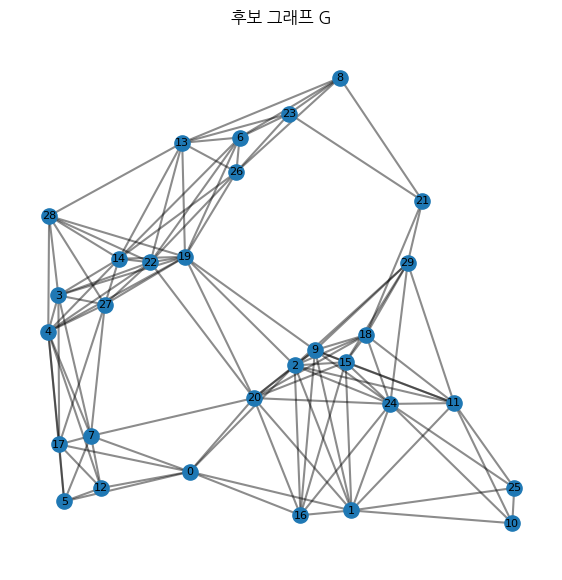

생성된 후보 그래프
- 꼭짓점의 수: 30
- 변의 수: 117
후보 그래프의 총 가중치 합: 26.025


In [ ]:
def euclidean_distance(p, q):
    return math.hypot(p[0] - q[0], p[1] - q[1])


def generate_connected_geometric_graph(n, radius, seed=0, max_tries=1000):
    rng = np.random.default_rng(seed)

    for trial in range(max_tries):
        trial_seed = seed + trial
        G = nx.random_geometric_graph(n, radius, seed=trial_seed)
        pos = nx.get_node_attributes(G, "pos")
        for u, v in G.edges():
            G[u][v]["weight"] = euclidean_distance(pos[u], pos[v])
        if nx.is_connected(G):
            return G, pos, trial_seed

    raise RuntimeError(
        "연결된 그래프를 만들지 못했습니다. RADIUS를 더 크게 설정해보세요."
    )


def edge_total_length(G):
    # 그래프에 있는 모든 변의 가중치(길이)를 더해서 총 길이를 구합니다.
    # G.edges(data=True)는 (꼭짓점1, 꼭짓점2, 속성정보)를 하나씩 꺼내줍니다.
    return sum(data["weight"] for _, _, data in G.edges(data=True))


def draw_graph(G, pos, title, edge_width=1.5):
    # 그림 크기를 7x7 인치로 설정합니다.
    plt.figure(figsize=(7, 7))
    # 변(연결선)을 그립니다. alpha는 투명도, width는 선 굵기입니다.
    nx.draw_networkx_edges(G, pos, alpha=0.45, width=edge_width)
    # 꼭짓점(점)을 그립니다.
    nx.draw_networkx_nodes(G, pos, node_size=120)
    # 꼭짓점 번호(이름)를 표시합니다.
    nx.draw_networkx_labels(G, pos, font_size=8)
    plt.title(title)
    plt.axis("equal")  # x축과 y축의 눈금 간격을 같게 맞춰 실제 모양이 왜곡되지 않게 합니다.
    plt.axis("off")    # 축 눈금과 테두리를 숨깁니다.
    plt.show()

G, pos, actual_seed = generate_connected_geometric_graph(N, RADIUS, SEED)

# 후보 그래프를 그림으로 확인합니다.
draw_graph(G, pos, "후보 그래프 G")

print(f"생성된 후보 그래프")
print(f"- 꼭짓점의 수: {G.number_of_nodes()}")
print(f"- 변의 수: {G.number_of_edges()}")
print(f"후보 그래프의 총 가중치 합: {edge_total_length(G):.3f}")

## 3. Kruskal 알고리즘으로 MST 만들기

MST를 구하는 대표적인 방법에는 Kruskal 알고리즘과 Prim 알고리즘이 있습니다.
먼저 두 알고리즘을 직접 코드로 구현해서 실제로 MST가 만들어지는 과정을 확인해보고,
마지막에 networkx가 제공하는 함수와 비교해봅니다.

Kruskal 알고리즘은 다음과 같은 순서로 동작합니다.

1. 모든 변을 가중치가 작은 순서로 정렬한다.
2. 가중치가 작은 변부터 하나씩 확인한다. 그 변의 두 꼭짓점이 지금까지 고른 변들만으로 이미 서로 연결되어 있다면(그 변을 추가하는 순간 순환이 생기므로) 넘어가고, 아직 연결되어 있지 않다면 MST에 추가한다.
3. 선택한 변의 수가 (꼭짓점의 수 - 1)이 되면 멈춘다.

"두 꼭짓점이 이미 연결되어 있는지"는 지금까지 고른 변들만으로 이루어진 그래프에서
두 꼭짓점 사이에 경로가 있는지 확인하면 됩니다.

In [ ]:
def kruskal_steps(G):
    """
    Kruskal 알고리즘의 진행 과정을 한 단계씩 기록해서 돌려줍니다.
    각 단계는 다음 정보를 담은 딕셔너리입니다.
    - edge: 이번에 검토한 변
    - accepted: 이 변을 MST에 채택했는지 여부 (False면 순환이 생겨서 기각)
    - mst_edges: 이 단계까지 채택된 변들의 모임
    """
    # mst_so_far: 우리가 변을 넣어가며 mst로 완성해갈 부분구조입니다.
    mst_so_far = nx.Graph()
    mst_so_far.add_nodes_from(G.nodes())

    # G의 변 전체를 가중치에 대해 오름차순으로 정렬합니다.
    sorted_edges = sorted(G.edges(data=True), key=lambda e: e[2]["weight"])

    steps = []
    mst_edges = []
    # 정렬된 변에서 하나를 가져옵니다. 변의 양 끝점은 u,v입니다.
    for u, v, data in sorted_edges:
        # accepted: u,v가 지금까지 채택된 변들만으로 이미 연결되어 있으면 거짓, 아니면 참의 값을 가집니다.
        accepted = not nx.has_path(mst_so_far, u, v)

        # accepted가 참인 경우 해당 변을 우리의 mst에 추가해줍니다.
        if accepted:
            mst_so_far.add_edge(u, v)
            mst_edges.append((u, v, data["weight"]))

        # 이번 단계의 상태를 기록합니다. mst_edges는 나중에 값이 바뀌지 않도록 복사해서 저장합니다.
        steps.append({
            "edge": (u, v),
            "weight": data["weight"],
            "accepted": accepted,
            "mst_edges": list(mst_edges),
        })

        # 최종적으로 mst가 spanning tree가 되면 알고리즘을 종료합니다.
        if len(mst_edges) == G.number_of_nodes() - 1:
            break

    return steps


def kruskal_mst(G):
    # 전체 단계를 진행한 뒤, 마지막 단계에 남은 MST 변 목록만 돌려줍니다.
    return kruskal_steps(G)[-1]["mst_edges"]

kruskal_edges = kruskal_mst(G)
kruskal_total = sum(weight for _, _, weight in kruskal_edges)

print("Kruskal 알고리즘 결과")
print(f"- 선택된 변의 수: {len(kruskal_edges)}")
print(f"- 총 변 길이: {kruskal_total:.3f}")

Kruskal 알고리즘 결과
- 선택된 변의 수: 29
- 총 변 길이: 3.509


아래 코드를 실행하면 Kruskal 알고리즘의 각 단계가 어떻게 실행되는지 확인할 수 있습니다. 실행된 결과 상단의 `단계` 옆의 동그란 슬라이더 핸들을 클릭한 뒤 키보드 좌,우 방향키를 눌러 각 단계를 확인해보세요. (코드의 내용을 이해할 필요는 **전혀** 없습니다. 그냥 실행만 하면 됩니다.)

In [ ]:
from ipywidgets import interact, IntSlider

def draw_step(G, pos, steps, step_index, title_prefix):
    step = steps[step_index]
    plt.figure(figsize=(7, 7))

    nx.draw_networkx_edges(G, pos, alpha=0.15, width=1)

    mst_edgelist = [(u, v) for u, v, _ in step["mst_edges"]]
    nx.draw_networkx_edges(G, pos, edgelist=mst_edgelist, width=2.5, edge_color="tab:blue")

    color = "tab:green" if step["accepted"] else "tab:red"
    style = "solid" if step["accepted"] else "dashed"
    nx.draw_networkx_edges(G, pos, edgelist=[step["edge"]], width=3.5, edge_color=color, style=style)

    nx.draw_networkx_nodes(G, pos, node_size=120)
    nx.draw_networkx_labels(G, pos, font_size=8)

    status = "채택" if step["accepted"] else "기각 (순환 발생)"
    plt.title(
        f"{title_prefix} — {step_index + 1}/{len(steps)}단계\n"
        f"검토한 변: {step['edge']} ({status}) · 지금까지 채택된 변: {len(step['mst_edges'])}개"
    )
    plt.axis("equal")
    plt.axis("off")
    plt.show()

kruskal_step_log = kruskal_steps(G)

interact(
    lambda step_index: draw_step(G, pos, kruskal_step_log, step_index, "Kruskal 알고리즘"),
    step_index=IntSlider(
        min=0, max=len(kruskal_step_log) - 1, step=1, value=0,
        description="단계", continuous_update=False,
    ),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='단계', max=55), Output()), _dom_c…

<function __main__.<lambda>(step_index)>

## 4. Prim 알고리즘으로 MST 만들기

Prim 알고리즘은 다음과 같은 순서로 동작합니다.

1. 아무 꼭짓점 하나에서 시작해서, 그 꼭짓점 하나만 포함된 그룹을 만든다.
2. 지금까지 만든 그룹과 그룹 밖의 꼭짓점을 잇는 변 중 가중치가 가장 작은 변을 골라 그룹에 추가한다.
3. 모든 꼭짓점이 그룹에 포함될 때까지 2번을 반복한다.

In [ ]:
def prim_steps(G, start=None):
    """
    Prim 알고리즘의 진행 과정을 한 단계씩 기록해서 돌려줍니다.
    각 단계는 다음 정보를 담은 딕셔너리입니다.
    - edge: 이번 단계에서 그룹에 새로 추가한 변
    - visited: 이번 단계까지 채택된 변들이 커버하는 꼭짓점들의 모임
    - mst_edges: 이 단계까지 채택된 변들의 모임
    """
    nodes = list(G.nodes())
    if start is None:
        start = nodes[0]  # 시작 꼭짓점을 정하지 않으면 첫 번째 꼭짓점에서 시작합니다.

    # visited: 지금까지 그룹(=완성되어 가는 MST)에 포함된 꼭짓점들의 모임입니다.
    visited = {start}

    steps = []
    mst_edges = []

    # 모든 꼭짓점이 그룹에 포함될 때까지 반복합니다.
    while len(visited) < len(nodes):
        best_edge = None
        best_weight = None

        # 그룹 안의 꼭짓점 u에서 출발해, 그룹 밖의 꼭짓점 v로 가는 변들을 전부 훑어보면서 가중치가 가장 작은 변을 직접 찾습니다.
        for u in visited:
            for _, v, data in G.edges(u, data=True):
                if v in visited:
                    continue  # 이미 그룹에 속한 꼭짓점으로 가는 변은 후보가 아닙니다.

                # 지금까지 찾은 후보들 중 가장 작은 가중치라면 갱신합니다.
                if best_weight is None or data["weight"] < best_weight:
                    best_weight = data["weight"]
                    best_edge = (u, v)

        # 그룹과 바깥을 잇는 가장 작은 변을 찾았으니, 그 변의 바깥쪽 꼭짓점을 그룹에 추가합니다.
        u, v = best_edge
        visited.add(v)
        mst_edges.append((u, v, best_weight))

        # 이번 단계의 상태를 기록합니다. mst_edges는 나중에 값이 바뀌지 않도록 복사해서 저장합니다.
        steps.append({
            "edge": (u, v),
            "weight": best_weight,
            "accepted": True,
            "mst_edges": list(mst_edges),
        })

    return steps


def prim_mst(G, start=None):
    # 전체 단계를 진행한 뒤, 마지막 단계에 남은 MST 변 목록만 돌려줍니다.
    return prim_steps(G, start)[-1]["mst_edges"]


prim_edges = prim_mst(G)
prim_total = sum(weight for _, _, weight in prim_edges)

print("Prim 알고리즘 결과")
print(f"- 선택된 변의 수: {len(prim_edges)}")
print(f"- 총 변 길이: {prim_total:.3f}")

Prim 알고리즘 결과
- 선택된 변의 수: 29
- 총 변 길이: 3.509


수업시간에 다루었듯 두 알고리즘은 서로 같지 않을 수는 있어도 같은 가중치를 가지는 생성수형도를 반환합니다. 이 문제의 경우 두 알고리즘이 같은 생성수형도를 반환합니다.

In [ ]:
print("Kruskal과 Prim 비교")
print(f"- 동형(isomorphic)인가?: {nx.is_isomorphic(nx.Graph([(u, v) for u, v, _ in kruskal_edges]), nx.Graph([(u, v) for u, v, _ in prim_edges]))}")

print(f"- Kruskal 총 변 길이: {kruskal_total:.10f}")
print(f"- Prim 총 변 길이: {prim_total:.10f}")
print(f"- 두 값이 (거의) 같은가?: {abs(kruskal_total - prim_total) < 1e-9}")

Kruskal과 Prim 비교
- 동형(isomorphic)인가?: True
- Kruskal 총 변 길이: 3.5085102050
- Prim 총 변 길이: 3.5085102050
- 두 값이 (거의) 같은가?: True


위에서와 동일하게 아래 코드를 실행하여 Prim알고리즘의 각 단계를 확인해보세요.

In [ ]:
prim_step_log = prim_steps(G)

interact(
    lambda step_index: draw_step(G, pos, prim_step_log, step_index, "Prim 알고리즘"),
    step_index=IntSlider(
        min=0, max=len(prim_step_log) - 1, step=1, value=0,
        description="단계", continuous_update=False,
    ),
)

interactive(children=(IntSlider(value=0, continuous_update=False, description='단계', max=28), Output()), _dom_c…

<function __main__.<lambda>(step_index)>

### 생각해 볼 문제
- Kruskal 알고리즘과 Prim 알고리즘 중 더 단계가 많이 걸린 것이 무엇일까요?
- 단계가 많다는게 무조건 오래 걸렸다는 얘기일까요? 다르게 말하면, 각 알고리즘에서 한 단계를 수행하는 데에 걸린 시간이 동일할까요?

## 5. networkx의 minimum_spanning_tree 함수

지금까지 Kruskal과 Prim 알고리즘을 직접 구현해서, 두 알고리즘이 만든 MST의 총 변 길이가 같을 뿐 아니라
두 그래프가 동형(isomorphic)이라는 것까지 확인했습니다.

사실 networkx에는 이 두 알고리즘을 포함한 MST 생성 알고리즘들이 이미 구현되어 있어서,
`algorithm` 옵션만 바꾸면 원하는 알고리즘으로 바로 MST를 계산할 수 있습니다.

우리가 만든 버전과 networkx의 버전은 알고리즘의 논리는 완전히 같지만, 내부적으로 구현된 방식은 다릅니다. 우리는 이해하기 쉬운 방식으로 직접 만들었고, networkx는 더 정교한 방식으로 구현되어 있어서 같은 결과를 훨씬 빠르게 계산해줍니다. 같은 알고리즘이라도 "어떻게 구현하느냐"에 따라 속도가 크게 달라질 수 있습니다.

<details>
<summary>알고리즘 개선 방법</summary>

- Kruskal 알고리즘: networkx는 내부적으로 최적화된 Union-Find(합집합-찾기) 자료구조(`networkx.utils.UnionFind`)를 씁니다. 이 구현체는 "무게 기준 합치기(union by rank/size)"와 "경로 압축(path compression)"까지 적용되어 있어서, 연산 하나하나가 사실상 상수 시간에 가깝게 동작합니다(엄밀히는 역 아커만 함수 수준). 이를 이용해 그래프 전체를 다시 뒤지지 않고도 "두 꼭짓점이 이미 같은 그룹에 속해 있는가"를 훨씬 빠르게
판단하고 여기에 더해 변 목록을 다루는 내부 데이터 구성도 반복적인 탐색이 필요 없도록
미리 정리해 둡니다.

- Prim 알고리즘: `heapq`라는 우선순위 큐 알고리즘을 통해 각 단계마다 가중치가 가장 작은 변을 구하지 않고 미리 구한 큐 내에서 변을 찾아 알고리즘을 적용합니다.

</details>

이제 이후 실습에서는 networkx의 결과를 MST로 사용합니다.

In [ ]:
# algorithm 옵션으로 어떤 알고리즘을 사용할지 고를 수 있습니다.
T_by_kruskal = nx.minimum_spanning_tree(G, weight="weight", algorithm="kruskal")
T_by_prim = nx.minimum_spanning_tree(G, weight="weight", algorithm="prim")

print(f"networkx(Kruskal) 총 변 길이: {edge_total_length(T_by_kruskal):.3f}")
print(f"networkx(Prim) 총 변 길이: {edge_total_length(T_by_prim):.3f}")

# 이후 실습에서는 networkx의 기본 알고리즘(Kruskal)으로 계산한 결과를 T로 사용합니다.
T = nx.minimum_spanning_tree(G, weight="weight")

print()
print("MST 계산 결과")
print(f"- 꼭짓점의 수: {T.number_of_nodes()}")
print(f"- 변의 수: {T.number_of_edges()}")
print(f"- 총 변 길이: {edge_total_length(T):.3f}")
print(f"- 꼭짓점의 수 - 1: {T.number_of_nodes() - 1}")  # 수형도라면 (변의 수) = (꼭짓점의 수) - 1이 성립해야 합니다.
print(f"- 수형도인가?: {nx.is_tree(T)}")

print()
print("직접 구현한 알고리즘과 결과가 같은가?")
print(f"- Kruskal(직접 구현) vs networkx: {abs(kruskal_total - edge_total_length(T)) < 1e-9}")
print(f"- Prim(직접 구현) vs networkx: {abs(prim_total - edge_total_length(T)) < 1e-9}")

networkx(Kruskal) 총 변 길이: 3.509
networkx(Prim) 총 변 길이: 3.509

MST 계산 결과
- 꼭짓점의 수: 30
- 변의 수: 29
- 총 변 길이: 3.509
- 꼭짓점의 수 - 1: 29
- 수형도인가?: True

직접 구현한 알고리즘과 결과가 같은가?
- Kruskal(직접 구현) vs networkx: True
- Prim(직접 구현) vs networkx: True


In [ ]:
# %timeit은 같은 코드를 여러 번 반복 실행해서 평균 실행 시간을 알려주는 주피터 매직 명령입니다.

print("직접 구현한 Kruskal:")
%timeit kruskal_mst(G)

print("\n직접 구현한 Prim:")
%timeit prim_mst(G)

print("\nnetworkx의 minimum_spanning_tree (Kruskal):")
%timeit nx.minimum_spanning_tree(G, weight="weight", algorithm="kruskal")

print("\nnetworkx의 minimum_spanning_tree (Prim):")
%timeit nx.minimum_spanning_tree(G, weight="weight", algorithm="prim")

직접 구현한 Kruskal:
The slowest run took 4.26 times longer than the fastest. This could mean that an intermediate result is being cached.
1.54 ms ± 637 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

직접 구현한 Prim:
1.98 ms ± 429 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

networkx의 minimum_spanning_tree (Kruskal):
404 µs ± 124 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)

networkx의 minimum_spanning_tree (Prim):
272 µs ± 81.8 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


## 6. MST 시각화

MST는 후보 그래프의 변 중 일부만 남긴 것입니다. 수형도이므로 회로(cycle)가 없습니다.

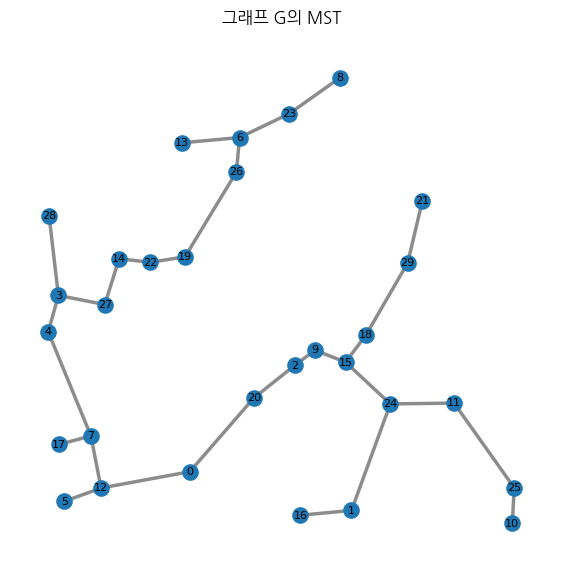

In [ ]:
# MST를 그림으로 확인합니다. 후보 그래프보다 선이 훨씬 적게 남는 것을 볼 수 있습니다.
draw_graph(T, pos, "그래프 G의 MST", edge_width=2.5)

## 7. 후보 그래프와 MST 비교

아래 표는 후보 그래프와 MST의 주요 지표를 비교합니다.

- 총 변 길이: 건설비 또는 유지비를 단순하게 모델링한 값
- 변 수: 남긴 연결의 개수
- 평균 최단거리: 그래프 안에서 두 꼭짓점 사이를 이동할 때의 평균 거리
- 지름(diameter): 가장 멀리 떨어진 두 꼭짓점 사이의 최단거리

In [ ]:
def average_shortest_path_length_weighted(G):
    # 모든 꼭짓점 쌍 사이의 최단거리를 한 번에 계산합니다. (가중치를 고려한 다익스트라 알고리즘 사용)
    lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight="weight"))
    nodes = list(G.nodes())
    total = 0
    count = 0

    # 서로 다른 꼭짓점 쌍을 한 번씩만 세면서 최단거리를 모두 더합니다.
    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            total += lengths[u][v]
            count += 1

    # (모든 쌍의 최단거리 합) / (쌍의 개수) = 평균 최단거리
    return total / count


def diameter_weighted(G):
    # 지름: 그래프 안에서 가장 멀리 떨어진 두 꼭짓점 사이의 최단거리
    lengths = dict(nx.all_pairs_dijkstra_path_length(G, weight="weight"))
    return max(max(d.values()) for d in lengths.values())


# 후보 그래프와 MST의 주요 지표를 한 표로 비교합니다.
summary = pd.DataFrame([
    {
        "구분": "후보 그래프",
        "꼭짓점 수": G.number_of_nodes(),
        "변 수": G.number_of_edges(),
        "총 변 길이": edge_total_length(G),
        "평균 최단거리": average_shortest_path_length_weighted(G),
        "지름": diameter_weighted(G),
        "수형도 여부": nx.is_tree(G),
    },
    {
        "구분": "MST",
        "꼭짓점 수": T.number_of_nodes(),
        "변 수": T.number_of_edges(),
        "총 변 길이": edge_total_length(T),
        "평균 최단거리": average_shortest_path_length_weighted(T),
        "지름": diameter_weighted(T),
        "수형도 여부": nx.is_tree(T),
    },
])

summary  # 표를 화면에 출력합니다.

,구분,꼭짓점 수,변 수,총 변 길이,평균 최단거리,지름,수형도 여부
0,후보 그래프,30,117,26.025472,0.544713,1.143235,False
1,MST,30,29,3.508510,0.936851,2.384916,True


## 8. MST의 우회율 확인

MST는 총 길이를 줄이지만, 두 꼭짓점 사이의 이동 거리를 크게 늘릴 수 있습니다.

여기서는 각 꼭짓점 쌍에 대해 다음 값을 계산합니다.

$$
\text{우회율}(u,v)
=
\frac{\text{MST에서 } u\text{와 }v\text{ 사이의 최단거리}}
{\text{후보 그래프에서 } u\text{와 }v\text{ 사이의 최단거리}}
$$

값이 클수록 MST에서 더 많이 돌아가야 한다는 뜻입니다.

In [ ]:
def stretch_statistics(original, subgraph):
    # 후보 그래프와 MST 각각에서, 모든 꼭짓점 쌍 사이의 최단거리를 미리 계산해둡니다.
    dist_original = dict(nx.all_pairs_dijkstra_path_length(original, weight="weight"))
    dist_sub = dict(nx.all_pairs_dijkstra_path_length(subgraph, weight="weight"))

    rows = []
    nodes = list(original.nodes())

    # 서로 다른 꼭짓점 쌍(u, v)마다 우회율을 계산해 표에 한 줄씩 추가합니다.
    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            d0 = dist_original[u][v]   # 후보 그래프에서의 최단거리
            d1 = dist_sub[u][v]        # MST에서의 최단거리
            rows.append({
                "u": u,
                "v": v,
                "원래_최단거리": d0,
                "MST_최단거리": d1,
                "우회율": d1 / d0,  # MST 최단거리가 원래보다 몇 배 늘어났는지
            })

    return pd.DataFrame(rows)


stretch_df = stretch_statistics(G, T)

print("MST 우회율 요약")
print(f"- 평균 우회율: {stretch_df['우회율'].mean():.3f}")
print(f"- 최대 우회율: {stretch_df['우회율'].max():.3f}")

# 우회율이 큰 순서로 정렬해 상위 10개 꼭짓점 쌍을 확인합니다.
stretch_df.sort_values("우회율", ascending=False).head(10)

MST 우회율 요약
- 평균 우회율: 1.667
- 최대 우회율: 7.400


,u,v,원래_최단거리,MST_최단거리,우회율
216,8,21,0.299550,2.216677,7.400034
400,21,23,0.321692,2.091302,6.500941
224,8,29,0.428997,2.087230,4.865372
173,6,21,0.433350,1.979644,4.568238
419,23,29,0.451140,1.961855,4.348665
403,21,26,0.481028,1.909640,3.969914
234,9,19,0.323762,1.276076,3.941401
73,2,19,0.312267,1.224505,3.921343
306,13,21,0.546298,2.096176,3.837060
15,0,16,0.240606,0.877800,3.648294


## 9. 우회율이 가장 큰 꼭짓점 쌍 살펴보기

아래 그림은 MST에서 가장 크게 우회하는 꼭짓점 쌍을 보여줍니다.

- 가장 굵게 강조된 선: 후보 그래프에서의 최단경로
- 중간 굵기의 선: MST
- 크게 표시된 점: 비교 대상 두 꼭짓점

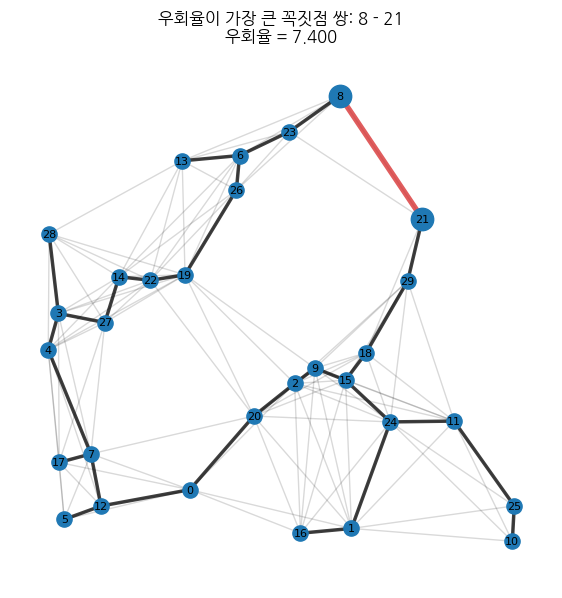

우회율이 가장 큰 꼭짓점 쌍
- 꼭짓점: 8, 21
- 후보 그래프 최단거리: 0.300
- MST 최단거리: 2.217
- 우회율: 7.400


In [ ]:
worst = stretch_df.sort_values("우회율", ascending=False).iloc[0]
u = int(worst["u"])
v = int(worst["v"])

path_original = nx.shortest_path(G, u, v, weight="weight")
path_tree = nx.shortest_path(T, u, v, weight="weight")

def path_edges(path):
    return list(zip(path[:-1], path[1:]))

plt.figure(figsize=(7, 7))

nx.draw_networkx_edges(G, pos, alpha=0.15, width=1)
nx.draw_networkx_edges(T, pos, alpha=0.75, width=2.5)
nx.draw_networkx_edges(G, pos, edgelist=path_edges(path_original), width=4, alpha=0.75, edge_color="tab:red")
nx.draw_networkx_nodes(G, pos, node_size=120)
nx.draw_networkx_nodes(G, pos, nodelist=[u, v], node_size=260)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title(
    f"우회율이 가장 큰 꼭짓점 쌍: {u} - {v}\n"
    f"우회율 = {worst['우회율']:.3f}"
)
plt.axis("equal")
plt.axis("off")
plt.show()

print("우회율이 가장 큰 꼭짓점 쌍")
print(f"- 꼭짓점: {u}, {v}")
print(f"- 후보 그래프 최단거리: {worst['원래_최단거리']:.3f}")
print(f"- MST 최단거리: {worst['MST_최단거리']:.3f}")
print(f"- 우회율: {worst['우회율']:.3f}")

## 10. 토론 질문

다음 질문에 답해보세요.

1. MST의 총 변 길이는 후보 그래프보다 얼마나 줄었는가?
2. MST의 평균 최단거리와 지름은 후보 그래프에 비해 어떻게 달라졌는가?
3. 가장 큰 우회율을 보인 꼭짓점 쌍은 실제 도로망에서 어떤 문제를 일으킬 수 있는가?
4. MST는 도로망 같은 실제 연결망의 최종 설계로 적합한 구조인가?
5. 연결성을 유지하는 부분구조를 찾고자 할 때 또 어떤 요소들을 고려할 수 있겠는가?

## 마무리

이번 실습에서 확인한 핵심은 다음과 같습니다.

- 가중치를 건설 비용이라고 하였을 때 MST는 가장 적은 비용으로 연결된 부분구조를 얻게 한다.
- 하지만 MST는 수형도이므로 순환이 없고, 어떤 변을 제거하더라도 연결성을 끊게 되며, 그 외 여러 요소에서 기존 그래프 대비 손해를 보는 부분이 존재한다.
- 도로망 같은 실제 연결망을 설계할 때는 건설비용 뿐만 아니라 다른 여러 가지 실질적인 요소들도 함께 고려해야 한다.